# Atividade de vendas no Brasil

Este notebook foi criado com o objetivo de estudar Python, NumPy, Pandas e Seaborn para análise de dados de vendas.

## Aviso
Como o objetivo é o aprendizado dessas ferramentas, há alguns comentários que escrevi em tom mais didático (que não estariam em desafios reais de dados), que representaram as minhas dúvidas e aprendizados. Isso se dá para facilitar consulta futura e estudo sobre análise de dados.

## Dataset
O dataset usado foi "vendas_brasil_1.csv", disponibilizado no github da liga, que reúne informações de vendas realizadas em diferentes cidades do Brasil, contendo dados como categoria dos produtos, canal de venda, quantidade vendida, preços, custos, descontos, frete, datas e receita. Essas informações permitem realizar análises, tratamento de dados e criação de visualizações para identificar padrões e apoiar a tomada de decisão.

## Organização
O notebook está dividido em três partes:
1. Utilização de NumPy para cálculos;
2. Tratamento e exploração dos dados com Pandas;
3. Criação de visualizações utilizando Seaborn.



## Entregável 1 NumPy



In [ ]:
import pandas as pd
import numpy as np

vendas = pd.read_csv('vendas_brasil_1.csv')

vendas.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## 1.a) Criando Arrays

Foram criados arraus de preço unitário, custo unitário, quantidade, desconto, receita total e frete, facilitando uso em contas de forma simples e rápida.

### Diferença entre Arrays x Df
- Transformar em arrays: operações matemáticas ficam mais simples e rapidas, e possibilita usar muitas funções do numpy (basicamente facilita cálculos matemáticos)
- Transformar em dataframes (df): facilita visualização e organização



In [ ]:
## diferenciar df de array
print("Preco Unit Dataframe para entender a diferenca:\n",vendas['preco_unitario'].head())

## arrays
preco_unit = vendas['preco_unitario'].to_numpy()
print("\nPreco Unit Array: ",preco_unit[:5])

custo_unit = vendas['custo_unitario'].to_numpy()
print("\n\nCusto: ",custo_unit[:5])

quantidade = vendas['quantidade'].to_numpy()
print("\n\nQuantidade: ",quantidade[:5])

desconto = vendas['desconto_pct'].to_numpy()
print("\n\nDesconto percentual: ",desconto[:5])

receita_total = vendas['receita_total'].to_numpy()
print("\n\nReceita total: ",receita_total[:5])

frete = vendas['frete'].to_numpy()
print("\n\nFrete: ",frete[:5])


Preco Unit Dataframe para entender a diferenca:
 0    739.39
1    187.48
2     76.11
3    145.86
4    133.92
Name: preco_unitario, dtype: float64

Preco Unit Array:  [739.39 187.48  76.11 145.86 133.92]


Custo:  [561.75 135.15  61.4   88.53 107.25]


Quantidade:  [10  5 14 11  1]


Desconto percentual:  [ 5.2  0.6  0.7  0.6 19.5]


Receita total:  [6933.48  930.28 1058.5  1592.43  107.64]


Frete:  [ 8.68   nan  7.98 20.49 22.89]


## 1.b) Cálculos com operações vetorizadas

- Os cálculos acaram ficando com muitas casas decimais.
- Para resolver isso, utilizei: np.set_printoptions(precision=2, suppress=True)
  - Precision=2 significa 2 casas decimais.


In [ ]:

np.set_printoptions(precision=2, suppress=True)

valor_bruto = preco_unit * quantidade
print("\n\nValor cheio: ",valor_bruto[:5])

valor_do_desconto = valor_bruto*desconto/100
print("\n\nValor do desconto: ",valor_do_desconto[:5])

valor_liquido = valor_bruto - valor_do_desconto
print("\n\nValor pago: ",valor_liquido[:5])

custo_total = custo_unit * quantidade
print("\n\nCusto total: ",custo_total[:5])

lucro_real = valor_liquido - custo_total
print("\n\nLucro real: ",lucro_real[:5])

lucro_estimado = valor_bruto - custo_total
print("\n\nLucro estimado: ",lucro_estimado[:5])



Valor cheio:  [7393.9   937.4  1065.54 1604.46  133.92]


Valor do desconto:  [384.48   5.62   7.46   9.63  26.11]


Valor pago:  [7009.42  931.78 1058.08 1594.83  107.81]


Custo total:  [5617.5   675.75  859.6   973.83  107.25]


Lucro real:  [1391.92  256.03  198.48  621.      0.56]


Lucro estimado:  [1776.4   261.65  205.94  630.63   26.67]


## 1.c) Máscaras booleanas

As máscaras booleanas permitem selecionar apenas as linhas que atendem a alguma condição. Dessa forma fica mais fácil filtrar informações específicas sem alterar o dataset original.

### Média .mean()
Para identificar valores acima da média, foi utilizada .mean() que retorna o valor médio do array.
- np.mean(matriz[linhaInicial:linhaFinal+1],indiceColuna)
- np.mean(matriz[linhaInicial:linhaFinal+1],axil=0)
  - calcula média de todas as colunas
  - resultado é algo como: [40. 50. 60.]

### Linhas e colunas .shape
Retorna a quantidade de linhas e colunas do dataset.

- `.shape[0]` → linhas
- `.shape[1]` → colunas

### np.percentile()
- `.percentile(desconto,90)` → Retorna os 10% maiores valores da coluna desconto

In [ ]:
receitaMedia = receita_total.mean()

total_vendas = vendas.shape[0]

print(f"{receitaMedia:.2f}")

vendas_acima_media = receita_total > receitaMedia # da um true/false que posso usar para tabela[criterio] e vai mostrar as linhas que o criterio eh true
#print("Vendas acima da media: ",vendas[vendas_acima_media].head())
print(f"Quantidade total: {total_vendas}| Acima da media: {np.sum(vendas_acima_media)}")

vendas_prejuizo = lucro_real < 0
#print("\n Vendas com prejuizo:",vendas[vendas_prejuizo].head())
print(f"Percentual de vendas com prejuizo: {np.sum(vendas_prejuizo)*100/total_vendas:.2f}%")

vendas_desconto_alto = desconto >= desconto.mean()
#print(f"\nvendas com desconto acima da media (acima de: {desconto.mean():.2f})",vendas[vendas_desconto_alto].head())

corte = np.percentile(desconto, 90)
vendas_desconto_alto = desconto >= corte
print(f"\nvendas com desconto acima do corte (acima de: {corte})",vendas[vendas_desconto_alto].head())

1891.69
Quantidade total: 37617| Acima da media: 9236
Percentual de vendas com prejuizo: 7.59%

vendas com desconto acima do corte (acima de: 24.4)     data_venda  mes          cidade  canal_venda    categoria  \
9   2023-04-12    4  Rio de Janeiro   App Mobile    Vestuário   
17  2022-05-11    5  Belo Horizonte   App Mobile  Eletrônicos   
24  2022-07-11    7          Recife   App Mobile    Vestuário   
33  2022-02-28    2        Curitiba     Site Web    Vestuário   
34  2023-05-26    5          Recife  Marketplace       Livros   

                 produto        vendedor fidelidade_cliente  preco_unitario  \
9                Bermuda        Ana Lima             Bronze          191.19   
17            Smartwatch     Elisa Costa              Prata          732.37   
24               Jaqueta        Ana Lima             Bronze          186.43   
33           Calça Jeans  Diego Ferreira              Prata          148.35   
34  Estatística Aplicada        Ana Lima              Prata       

## 1.d) Agregações


In [ ]:

receita_media = np.mean(receita_total)
maior_receita = np.max(receita_total)
menor_receita = np.min(receita_total)
print(f"Para receitas, a media foi: {receita_media:.2f}; sendo a maior: {maior_receita:.2f}; e a menor: {menor_receita:.2f}")
print(f"15% das vendas estao abaixo de {np.percentile(receita_total,15):.2f} reais; enquanto as 20% maiores receitas estao acima de {np.percentile(receita_total,80):.2f} reais")

lucro_medio = np.mean(lucro_real)
quantidade_vendas_prejuizo = np.sum(lucro_real < 0)
print(f"Lucro medio eh {lucro_medio:.2f} reais, tendo {quantidade_vendas_prejuizo} vendas com prejuizo. Isso representa: {quantidade_vendas_prejuizo*100/total_vendas:.2f}% das vendas")

Para receitas, a media foi: 1891.69; sendo a maior: 58430.28; e a menor: 3.70
15% das vendas estao abaixo de 225.25 reais; enquanto as 20% maiores receitas estao acima de 2416.67 reais
Lucro medio eh 342.03 reais, tendo 2857 vendas com prejuizo. Isso representa: 7.59% das vendas


## Entregável 2 Pandas

In [ ]:
vendas.head()


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [ ]:
vendas.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [ ]:
vendas.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [ ]:
vendas.shape # .shapes[0] linhas // [1] colunas

(37617, 21)

In [ ]:
vendas.isna().sum()

,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


# Visão geral do dataset

## Linhas e colunas
O dataset é formado por 37617 vendas distribuidas em linhas; e possui 21 colunas, cada qual registrando uma informação sobre a venda.

## Dados faltantes
Usando o "vendas.isna().sum()" percebeu-se 50 valores ausentes em canal_venda, que registra por qual canal ocorreu a venda (App mobile, site web, etc); 40 faltas em nome do vendedor; 82 faltas em margem_pct; 1879 faltas em frete; 2955 faltas em avaliacao_cliente; e 1504 faltas em prazo_entrega_dias.

## Colunas numéricas
- preco_unitario;
- custo_unitario;
- margem_pct;
- quantidade;
- desconto_pct;
- receita_total;
- frete;
- avaliacao_cliente;
- prazo_entrega_dias.

## Colunas categóricas
- cidade;
- canal_venda;
- categoria;
- produto;
- vendedor;
- fidelidade_cliente;
- devolucao;
- entrega_no_prazo;
- alta_temporada;
- flag_outlier_preco

## Colunas temporais
- data_venda;
- Mes (embora registrada com números de 1 a 12, ele representa cada mês e não quantidade em si);



## 2.b) Limpeza e tratamento

### Datetime
A coluna `data_venda` foi convertida para o tipo `datetime`, facilitando análises por ano e mês.
- Como as datas estavam em formatos diferentes (com "/" e "-"), utilizei `format="mixed"`.
- e utilizei `dayfirst=true` pois está no formato brasileiro (com dia na frente)

### Unique()
Utilizei o `.unique()` para identificar se houve variação na escrita de palavras como "sp" e "sao paulo".

### Padronização de escritas
Na coluna `canal_venda`, foram removidos espaços extras, padronizadas letras maiúsculas e minúsculas, retirados os acentos e corrigidos alguns valores escritos de formas diferentes, como "Siteweb" para "Site Web". Os valores ausentes dessa coluna foram preenchidos com **"Não Informado"**, já que não seria possível descobrir o canal correto.

Também foi feita uma padronização na coluna `cidade`, corrigindo abreviações e erros de escrita, para evitar que uma mesma cidade fosse considerada como cidades diferentes durante as análises.

Nem todas as limpezas devidas foram feitas, apenas algumas para aprendizado.

In [ ]:

vendas['data_venda'] = pd.to_datetime(vendas['data_venda'], dayfirst=True, format='mixed') # dayfirst=true pq formato br com dia antes e mixed pq tem "-" e "/"
vendas['data_venda'].dtype


vendas["canal_venda"].unique()
vendas["canal_venda"] = vendas["canal_venda"].str.strip().str.title() #strip remove espaco antes e dps do texto " a" --> "a" e title arruma maiuscula e minuscula
vendas['canal_venda'] = vendas['canal_venda'].str.normalize('NFKD').str.encode('ASCII', errors='ignore').str.decode('utf-8') # remove acento
vendas['canal_venda'] = vendas['canal_venda'].replace({'Siteweb': 'Site Web'})
vendas['canal_venda'] = vendas['canal_venda'].fillna('Não Informado') # como se trata de categoria, faz sentido colocar o nao informado nesse caso ao inves de supor algo
vendas["canal_venda"].unique()

vendas["cidade"] = vendas["cidade"].str.strip().str.title()
vendas['cidade'] = vendas['cidade'].replace(['Rj', 'Rio'], value='Rio De Janeiro')
vendas['cidade'] = vendas['cidade'].replace(['Sao Paulo', 'Sp','S. Paulo'], value='São Paulo')
vendas['cidade'] = vendas['cidade'].replace(['Slavador'], value='Salvador')
vendas['cidade'] = vendas['cidade'].replace(['Curtiba'], value='Curitiba')
vendas['cidade'] = vendas['cidade'].replace(['Bh','B. Horizonte'], value='Belo Horizonte')
print(vendas['cidade'].unique())
#vendas["categoria"].unique()
#vendas.head()

['Rio De Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba']


## 2.c) Criacao de novas colunas

In [ ]:

vendas['mes'] = vendas['data_venda'].dt.month
vendas['ano'] = vendas['data_venda'].dt.year
vendas['custo_total'] = vendas['custo_unitario'] * vendas['quantidade']
vendas['lucro_real'] = vendas['receita_total'] - vendas['custo_total']
vendas['tipo_venda'] = vendas['canal_venda'].apply(lambda x: 'Presencial' if x == 'Loja Fisica' else 'Remoto')

vendas.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,custo_total,lucro_real,tipo_venda
0,2022-04-13,4,Rio De Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,4.92,5.0,False,True,False,False,2022,5617.50,1315.98,Remoto
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,4.98,19.0,True,False,False,False,2023,675.75,254.53,Remoto
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,3.47,NaN,True,True,False,False,2022,859.60,198.90,Remoto
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,4.50,16.0,False,True,False,False,2022,973.83,618.60,Remoto
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,3.49,13.0,False,True,False,False,2022,107.25,0.39,Remoto


## 2.d) Criacao de filtros

In [ ]:
vendas['receita_total'].mean()
filtro_receitas_altas = vendas[vendas['receita_total'] > 2000]
filtro_receitas_altas['receita_total'].head()


filtro_devolucao = vendas[vendas['devolucao'] == 1]
filtro_devolucao.head()

filtro_vendas_manaus = vendas[vendas['cidade'] == 'Manaus']
filtro_vendas_manaus.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,custo_total,lucro_real,tipo_venda
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,4.98,19.0,True,False,False,False,2023,675.75,254.53,Remoto
6,2022-01-21,1,Manaus,Site Web,Livros,Python para Dados,Henrique Dias,Bronze,124.28,83.82,...,1.99,3.0,False,True,True,False,2022,502.92,225.69,Remoto
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,3.03,18.0,True,False,False,False,2023,129.72,51.63,Remoto
18,2023-10-24,10,Manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,NaN,16.0,True,True,False,False,2023,165.04,99.72,Remoto
23,2023-01-21,1,Manaus,Site Web,Esportes,Bicicleta,Carla Mendes,Bronze,257.83,207.71,...,3.99,13.0,False,True,True,False,2023,2492.52,1798.88,Remoto


## 2.e) Agrupamento

O `groupby` permite agrupar os dados e resumir informações por categoria, cidade ou canal de venda. Assim fica mais fácil comparar os resultados entre diferentes grupos.

Nesse caso fiz agrupamentos de receita_total por mês em ordem crescente; soma de receita_total por categoria em ordem decrescente; vendas médias por cidade e um resumo por cada categoria. Nesse último, usei o `.agg()` que permite calcular várias informações diferentes de uma só vez.

In [ ]:
receita_max_mes = vendas.groupby('mes')['receita_total'].max().sort_values() # em ordem crescente
receita_max_mes

receita_por_categoria = vendas.groupby('categoria')['receita_total'].sum().sort_values(ascending=False) #agrupo por categoria somando receita_total e colocando em ordem decrescente
receita_por_categoria

receita_media_cidade= vendas.groupby('cidade')['receita_total'].mean()
receita_media_cidade

qtd_vendas_cidade = vendas.groupby('cidade')['data_venda'].count().sort_values(ascending=False)
qtd_vendas_cidade

resumo_categoria = vendas.groupby('categoria')['receita_total'].agg(['sum', 'mean', 'max','size']) #.agg permite usar varios. size faz >contagem< de vendas para cada categoria
resumo_categoria


,sum,mean,max,size
categoria,,,,
Alimentação,3331601.51,445.878146,2025.55,7472
Eletrônicos,45017479.88,5990.349951,51003.49,7515
Esportes,11567480.75,1512.880035,58430.28,7646
Livros,4462597.93,602.565208,13367.63,7406
Vestuário,6780473.93,894.757710,19882.04,7578


## 2.f) Merge

- O `merge` permite juntar informações de duas tabelas usando uma coluna em comum.
- Nesse caso, foi criada uma tabela com o percentual de comissão de cada categoria e depois ela foi unida ao dataset principal. Com isso, foi possível calcular o gasto com comissão de cada venda e analisar quanto cada categoria gerou de comissão.

In [ ]:
regras_comissao = {'categoria': ['Alimentação','Eletrônicos', 'Vestuário', 'Esportes', 'Livros'],'pct_comissao': [0.12,0.03, 0.10, 0.08, 0.05]}
df_comissao = pd.DataFrame(regras_comissao)

vendas_analise = pd.merge(vendas, df_comissao, on='categoria', how='left')

vendas_analise['gasto_com_comissao'] = vendas_analise['receita_total'] * vendas_analise['pct_comissao']

custo_comissao_categoria = vendas_analise.groupby('categoria')['gasto_com_comissao'].sum().sort_values(ascending=False)

custo_comissao_categoria

,gasto_com_comissao
categoria,
Eletrônicos,1.350524e+06
Esportes,9.253985e+05
Vestuário,6.780474e+05
Alimentação,3.997922e+05
Livros,2.231299e+05


# Entregável 3 Seaborn

## 3.a) Gráfico de Barras para Receita

Para entender melhor qual categoria de produto traz mais retorno financeiro, resolvi montar um gráfico de barras comparando a receita total de cada uma. Dá pra ver de forma bem rápida quais categorias se destacam.

Usei o `sns.barplot()` do Seaborn para montar o gráfico, e apliquei a paleta `viridis` só para dar um contraste melhor entre as barras. Também fiz alguns ajustes visuais com o Matplotlib: girei os rótulos do eixo X em 45 graus (`plt.xticks(rotation=45)`) porque os nomes das categorias estavam se sobrepondo, e usei `sns.despine()` pra tirar as bordas de cima e da direita do gráfico — deixa o visual mais limpo, sem tanta poluição.



/tmp/ipykernel_1518/503215738.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_por_categoria, x='categoria', y='receita_total', palette='viridis', linewidth=1.5)


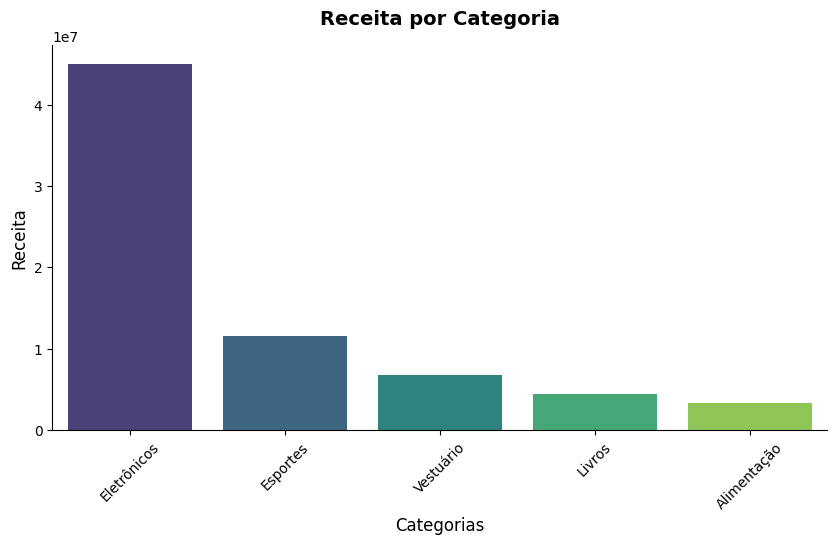

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

receita_por_categoria = vendas.groupby('categoria')['receita_total'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=receita_por_categoria, x='categoria', y='receita_total', palette='viridis', linewidth=1.5)
plt.title('Receita por Categoria', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categorias', fontsize=12)
plt.ylabel('Receita', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()

## 3.b) Gráfico de Linhas para Evolução Temporal

Para ver como a receita se comportou ao longo do ano, agrupei os dados por mês e plotei numa linha contínua — assim fica fácil enxergar tendências de alta ou queda ao longo do tempo.

Usei `sns.lineplot()` com `marker='o'`, que coloca uma bolinha em cada ponto e ajuda a destacar a transição de um mês para o outro. Também forcei o eixo X a mostrar todos os meses de 1 a 12 com `plt.xticks(range(1, 13))`, porque por padrão o gráfico ia mostrar só alguns meses de forma automática.

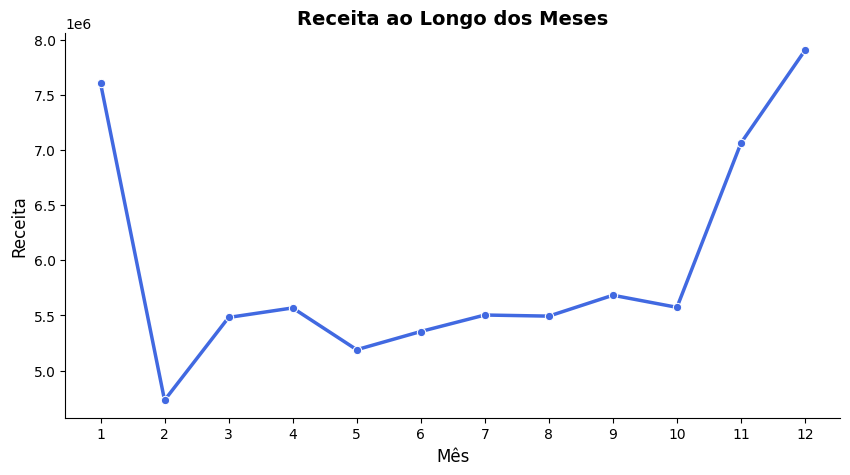

In [ ]:
receita_mensal = vendas.groupby('mes')['receita_total'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=receita_mensal, x='mes', y='receita_total', linewidth=2.5, marker='o', color='royalblue')

plt.title('Receita ao Longo dos Meses', fontsize=14, weight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita', fontsize=12)
plt.xticks(range(1, 13))
sns.despine()

plt.show()

## 3.c) Gráfico de Dispersão e Amostragem

Checar se existe alguma relação entre o preço unitário e a quantidade comprada.



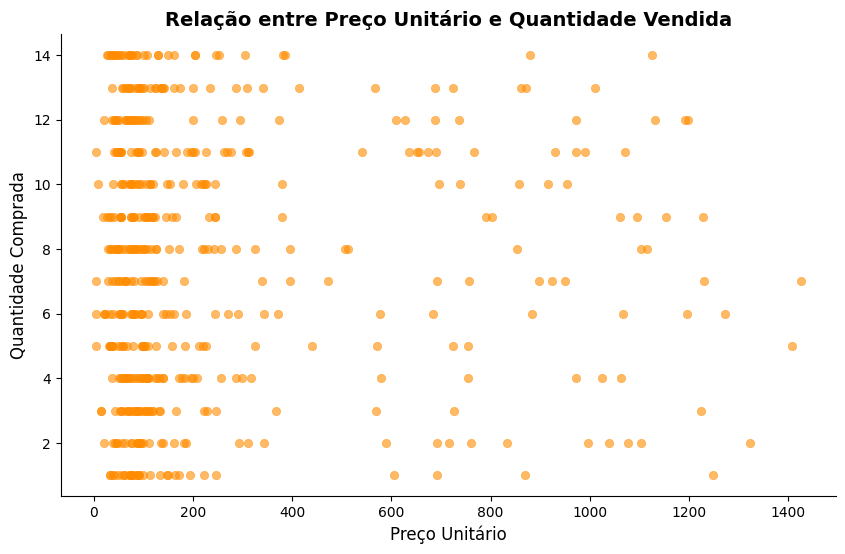

In [ ]:
amostra_vendas = vendas.sample(n=500, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=amostra_vendas, x='preco_unitario', y='quantidade', alpha=0.6, color='darkorange', edgecolor=None)

plt.title('Relação entre Preço Unitário e Quantidade Vendida', fontsize=14, weight='bold')
plt.xlabel('Preço Unitário', fontsize=12)
plt.ylabel('Quantidade Comprada', fontsize=12)
sns.despine()

plt.show()

## 3.d) Matriz de Correlação e Mapa de Calor

Por fim, usei um mapa de calor para comparar as colunas numéricas entre si e ver quais delas têm uma relação mais forte.

Antes de calcular a correlação, precisei filtrar o dataframe para manter só as colunas numéricas, com `.select_dtypes(include=['float64', 'int64'])` — sem isso o `.corr()` dá erro. Com as colunas certas, aplicar `.corr()` já traz os índices de correlação prontos.

Para visualizar, usei `sns.heatmap()`, com `annot=True` para mostrar o valor numérico dentro de cada quadradinho (facilita muito a leitura em vez de só olhar as cores). O `cmap='coolwarm'` deixa as correlações negativas em tons frios e as positivas em tons quentes, então dá pra identificar rapidinho onde estão as relações mais fortes.

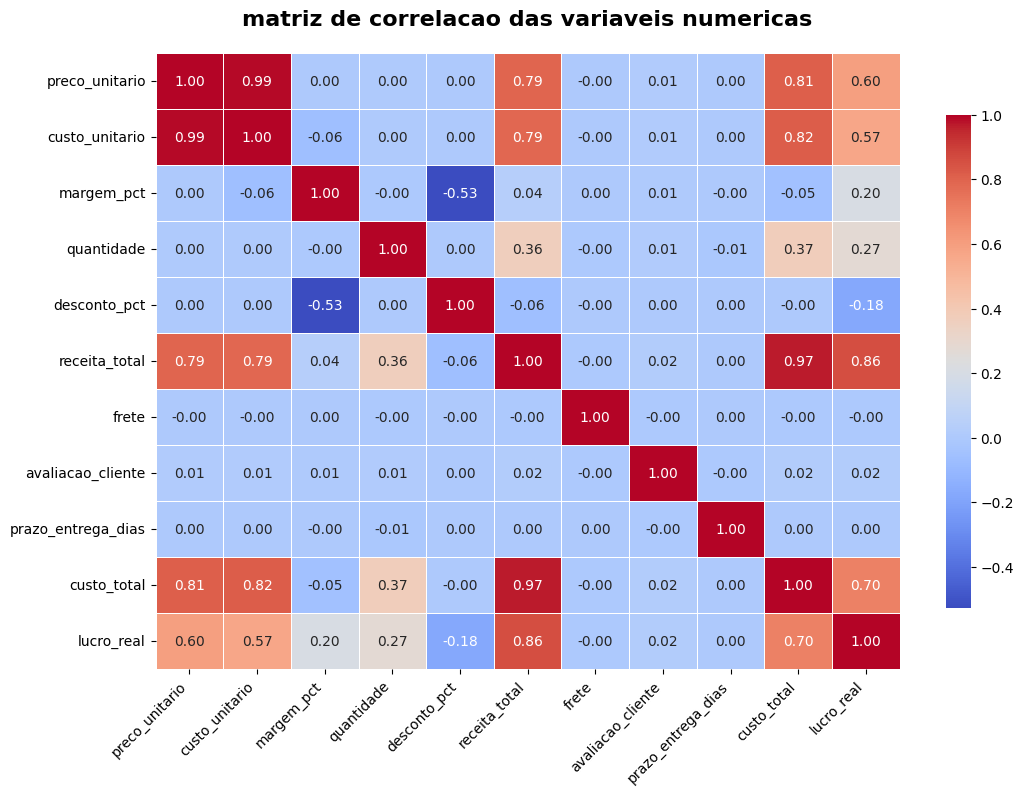

In [ ]:
colunas_numericas = vendas.select_dtypes(include=['float64', 'int64'])

matriz_correlacao = colunas_numericas.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})

plt.title('matriz de correlacao das variaveis numericas', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

plt.show()